In [171]:
! pip install pandas


In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
df = pd.read_csv('/Users/liamnguyen/Documents/MCI Python/Bài giảng/L9 - Final Project/data/transaction_data.csv')

In [174]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 516384 entries, 0 to 516383
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_num   516384 non-null  str    
 1   stock_code    516384 non-null  str    
 2   description   514945 non-null  str    
 3   quantity      516384 non-null  int64  
 4   invoice_date  516384 non-null  str    
 5   unit_price    516384 non-null  float64
 6   cust_id       389168 non-null  float64
 7   country       516384 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 31.5 MB


In [176]:
df.dropna( inplace = True)

In [177]:
df.isnull().sum()

invoice_num     0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
cust_id         0
country         0
dtype: int64

In [178]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['cust_id'] = df['cust_id'].astype(int)

In [179]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [180]:
df['quantity'] = df['quantity'].abs()
df['unit_price'] = df['unit_price'].abs()

In [181]:
df['amount'] = df['quantity'] * df['unit_price']
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [182]:
df['month'] = df['invoice_date'].dt.month
df['day'] = df['invoice_date'].dt.day
df['hour'] = df['invoice_date'].dt.hour
df['year_month'] = df['invoice_date'].dt.to_period('M').astype(str)
df['week_days'] = df['invoice_date'].dt.strftime('%a')


In [183]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,amount,month,day,hour,year_month,week_days
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,1,8,2010-12,Wed
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,1,8,2010-12,Wed
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed


Exploratory Data Analysis (EDA)

In [184]:
#Số lượng MAU mỗi tháng
df.groupby('year_month')['cust_id'].nunique().reset_index()

,year_month,cust_id
0,2010-12,948
1,2011-01,783
2,2011-02,798
3,2011-03,1020
4,2011-04,899
5,2011-05,1079
6,2011-06,1051
7,2011-07,993
8,2011-08,980
9,2011-09,1302


In [185]:
#số lượng order và tổng order
df.groupby('year_month').agg(
    number_of_orders = ('invoice_num', 'nunique'),
    total_order = ('amount','sum')

).reset_index()

,year_month,number_of_orders,total_order
0,2010-12,1708,590823.760
1,2011-01,1236,663815.700
2,2011-02,1202,457728.550
3,2011-03,1619,611036.910
4,2011-04,1384,512352.871
5,2011-05,1849,708938.040
6,2011-06,1707,714414.220
7,2011-07,1593,625943.541
8,2011-08,1544,674319.800
9,2011-09,2078,974236.392


In [186]:
#số lượng cust trong ngày và giờ
a1 = df.groupby('week_days')['cust_id'].nunique().reset_index()
display(a1)

a2 = df.groupby('hour')['cust_id'].nunique().reset_index()
display(a2)


,week_days,cust_id
0,Fri,1635
1,Mon,1721
2,Sun,1225
3,Thu,2119
4,Tue,1805
5,Wed,1890


,hour,cust_id
0,6,21
1,7,30
2,8,432
3,9,973
4,10,1365
5,11,1406
6,12,1685
7,13,1641
8,14,1470
9,15,1377


In [187]:
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,amount,month,day,hour,year_month,week_days
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,1,8,2010-12,Wed
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,1,8,2010-12,Wed
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed


In [188]:
#Top 10 nước sales nhiều nhất
df.groupby('country')['amount'].sum().sort_values(ascending = False).head(10)

country
United Kingdom    7202061.844
Netherlands        274503.120
EIRE               273825.110
Germany            227872.430
France             213830.250
Australia          139965.350
Spain               68018.650
Switzerland         57148.500
Belgium             40055.690
Sweden              39684.750
Name: amount, dtype: float64

In [189]:
# Chỉ số AOV
aov = df.groupby('country').agg(
    tổng_giá_trị_đơn_hàng = ('amount','sum'),
    số_lượng_đơn_hàng = ('invoice_num', 'nunique')
)
aov['AOV'] = aov['tổng_giá_trị_đơn_hàng']/aov['số_lượng_đơn_hàng']
aov.nlargest(3,'AOV')

,tổng_giá_trị_đơn_hàng,số_lượng_đơn_hàng,AOV
country,,,
Singapore,33438.19,10,3343.819000
Netherlands,274503.12,98,2801.052245
Australia,139965.35,69,2028.483333


Số lượng khách hàng mới và cũ so với trong tháng


In [190]:
first_time= df.groupby('cust_id')['year_month'].min().reset_index()
first_time.columns = ['cust_id', 'first_month']

In [191]:
df = df.merge(first_time, on='cust_id', how ='left')

In [192]:

df['type'] = df.apply(lambda row: 'new' if row['year_month'] == row['first_month'] else 'old', axis = 1 )
df.head()

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,amount,month,day,hour,year_month,week_days,first_month,type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,1,8,2010-12,Wed,2010-12,new
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed,2010-12,new
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,1,8,2010-12,Wed,2010-12,new
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed,2010-12,new
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed,2010-12,new


In [193]:
#chọn các khách hàng mới và giao dịch ở 12-2010
customer_type = 'new'
first_trans = '2010-12'
selected1 = df[(df['type'] == customer_type) & (df['year_month'] == first_trans)]['cust_id'].unique()
selected1


array([17850, 13047, 12583, 13748, 15100, 15291, 14688, 17809, 15311,
       14527, 16098, 18074, 17420, 16029, 16250, 12431, 17511, 17548,
       13705, 13747, 13408, 13767, 17924, 13448, 15862, 15513, 12791,
       16218, 14045, 14307, 17908, 17920, 12838, 13255, 16583, 18085,
       13758, 13694, 15983, 14849, 17968, 16210, 17897, 17377, 16552,
       17181, 17951, 14729, 12748, 15012, 12868, 17572, 14078, 14001,
       12662, 15525, 14237, 17905, 15485, 12433, 16955, 15350, 15605,
       18144, 15922, 14594, 15165, 14911, 16456, 17841, 12472, 17346,
       17643, 17873, 13093, 12921, 13468, 17760, 16928, 16048, 16274,
       14496, 14696, 16539, 17025, 13777, 17690, 12947, 17460, 18229,
       14142, 17069, 13065, 14606, 16835, 15235, 13576, 18011, 13090,
       15694, 14741, 13715, 14092, 17732, 12855, 15752, 17855, 14047,
       17925, 13941, 17017, 14135, 13108, 12471, 15601, 13418, 14766,
       15658, 14388, 14901, 18041, 15955, 15070, 16244, 15111, 14390,
       16546, 15260,

In [194]:
#những giao dịch của khách hàng mới t12/2010
selected2 = df[df['cust_id'].isin(selected1)]

In [195]:
#trung bình giá trị giao dịch của nhóm khách hàng mới T12/2010 khi họ quay lại
df2 = selected2.groupby('year_month').agg(
    total_amount = ('amount','sum'),
    num = ('invoice_num','nunique')
).reset_index()
df2['AOV'] = df2['total_amount']/df2['num']
df2.head()

,year_month,total_amount,num,AOV
0,2010-12,590823.76,1708,345.915550
1,2011-01,289669.44,689,420.420087
2,2011-02,244846.46,579,422.878169
3,2011-03,322860.27,753,428.765299
4,2011-04,213132.56,611,348.825794


In [196]:
df.head(3)

,invoice_num,stock_code,description,quantity,invoice_date,unit_price,cust_id,country,amount,month,day,hour,year_month,week_days,first_month,type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,1,8,2010-12,Wed,2010-12,new
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,2010-12,Wed,2010-12,new
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,1,8,2010-12,Wed,2010-12,new


In [197]:
maxTransDate = max(df['invoice_date'])
maxTransDate

Timestamp('2011-11-30 17:42:00')

In [198]:
#B1: frequency
rf_df = df.groupby(
    'cust_id'
).agg(
    last_trans_date = ('invoice_date','max'),
    Frequency = ('invoice_num','nunique')
).reset_index()

#B2: Recency
rf_df['Recency'] = (maxTransDate - rf_df['last_trans_date']).dt.days
rf_df.head()

,cust_id,last_trans_date,Frequency,Recency
0,12346,2011-01-18 10:17:00,2,316
1,12347,2011-10-31 12:25:00,6,30
2,12348,2011-09-25 13:13:00,4,66
3,12349,2011-11-21 09:51:00,1,9
4,12350,2011-02-02 16:01:00,1,301


In [201]:
#R_score
rf_df.loc[rf_df['Recency'] > 48, 'R_score'] = 1
rf_df.loc[(rf_df['Recency'] >= 15) & (rf_df['Recency'] <48)  , 'R_score'] = 2
rf_df.loc[rf_df['Recency'] <  15, 'R_score'] = 3

#F_score 
rf_df.loc[rf_df['Frequency'] ==1 , 'F_score'] = 1
rf_df.loc[(rf_df['Frequency'] >= 2) & (rf_df['Frequency'] <= 5), 'F_score'] = 2
rf_df.loc[rf_df['Frequency'] >5 , 'F_score'] = 3
rf_df.head()
rf_df.dropna(subset =[ 'R_score', 'F_score'], inplace = True)





In [203]:
rf_df['RF'] = rf_df['R_score'].astype(int).astype(str) + rf_df['F_score'].astype(int).astype(str)
segment_map = {
    '33': 'Loyal',
    '23': 'Losing loyal',
    '13': 'Lost loyal',
    '32': 'Potential loyal',
    '12': 'Losing potential loyal',
    '22': 'Losing potential loyal',
    '31': 'New customer',
    '11': 'Low value',
    '21': 'Low value',
}
rf_df['segment'] = rf_df['RF'].map(segment_map)
rf_df.head()

,cust_id,last_trans_date,Frequency,Recency,R_score,F_score,RF,segment
0,12346,2011-01-18 10:17:00,2,316,1.0,2.0,12,Losing potential loyal
1,12347,2011-10-31 12:25:00,6,30,2.0,3.0,23,Losing loyal
2,12348,2011-09-25 13:13:00,4,66,1.0,2.0,12,Losing potential loyal
3,12349,2011-11-21 09:51:00,1,9,3.0,1.0,31,New customer
4,12350,2011-02-02 16:01:00,1,301,1.0,1.0,11,Low value


In [207]:
rf_df.groupby('segment')['cust_id'].count().reset_index()

,segment,cust_id
0,Losing loyal,322
1,Losing potential loyal,1488
2,Lost loyal,180
3,Low value,1230
4,Loyal,524
5,New customer,115
6,Potential loyal,434


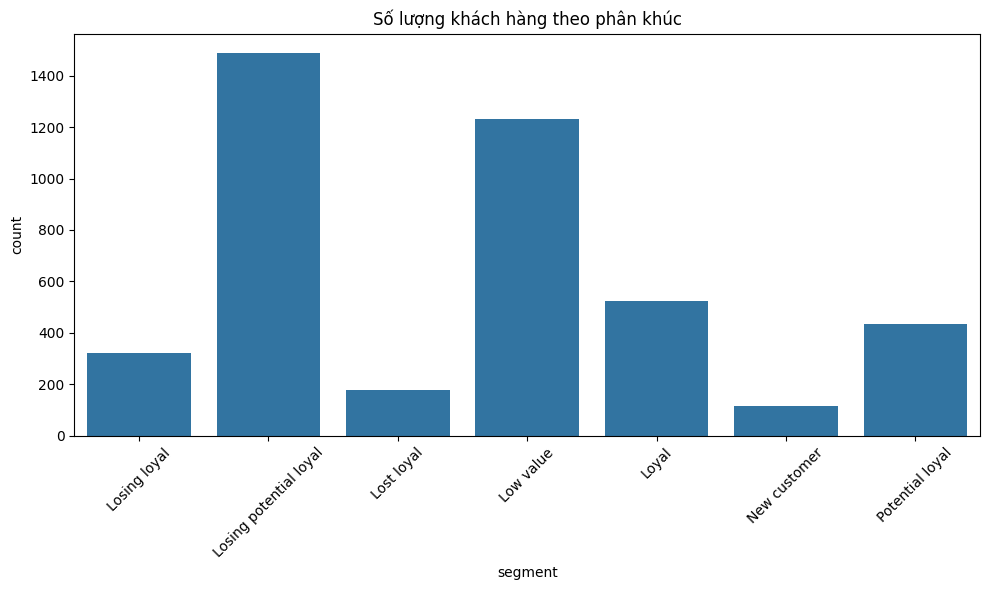

In [209]:
# số lượng khách hàng mỗi phân khúc

segment_count = rf_df.groupby('segment')['cust_id'].count().reset_index()
segment_count.columns = ['segment', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_count, x='segment', y='count')
plt.xticks(rotation=45)
plt.title('Số lượng khách hàng theo phân khúc')
plt.tight_layout()
plt.show()

In [212]:
df2 = df.merge(rf_df, on = 'cust_id', how = 'left')
s1 = df2.groupby('segment')['amount'].sum().reset_index()

s1['Per'] = s1['amount']/s1['amount'].sum()*100

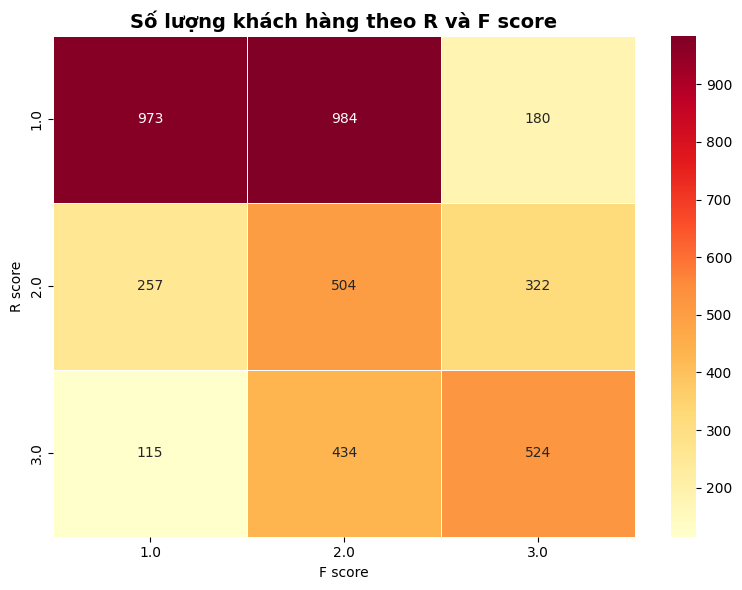

In [215]:
pivot = rf_df.groupby(['R_score', 'F_score'])['cust_id'].count().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Số lượng khách hàng theo R và F score', fontsize=14, fontweight='bold')
plt.xlabel('F score')
plt.ylabel('R score')
plt.tight_layout()
plt.show()